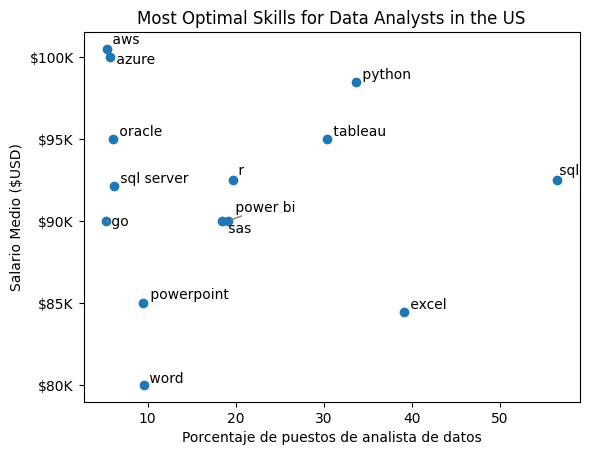

In [5]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import sys
!{sys.executable} -m pip install adjustText
from adjustText import adjust_text


dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df = df.dropna(subset="salary_year_avg")
df = df[df["job_title_short"] == "Data Analyst"]
df_exploded = df.explode("job_skills")

df_skills = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_skills = df_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
total_skills = len(df["job_skills"])-1
df_skills["skill_percent"] = df_skills["skill_count"]*100/total_skills
df_percentage = df_skills[df_skills["skill_percent"] >= 5]



plt.scatter(df_percentage['skill_percent'], df_percentage['median_salary'])
plt.xlabel('Porcentaje de puestos de analista de datos')
plt.ylabel('Salario Medio ($USD)')  
plt.title('Most Optimal Skills for Data Analysts in the US')


ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis


texts = []
for i, txt in enumerate(df_percentage.index):
    texts.append(plt.text(df_percentage['skill_percent'].iloc[i], df_percentage['median_salary'].iloc[i], " " + txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()